
https://archive.ics.uci.edu/dataset/14/breast+cancer


In [37]:

import numpy as np
import pandas as pd

from sklearn.naive_bayes import GaussianNB

In [38]:

data = pd.read_csv('datasets-uci-breast-cancer.csv')
dataset = data
dataset

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no','recurrence-events'
1,'50-59','ge40','15-19','0-2','no','1','right','central','no','no-recurrence-events'
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no','recurrence-events'
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes','no-recurrence-events'
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no','recurrence-events'
...,...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no','no-recurrence-events'
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes','no-recurrence-events'
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no','no-recurrence-events'
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no','no-recurrence-events'


In [39]:

print(dataset.isna().sum())

age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
Class          0
dtype: int64


In [40]:
# Encode target label

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

dataset['Class'] = label_encoder.fit_transform(dataset['Class'])


In [41]:

dataset

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no',1
1,'50-59','ge40','15-19','0-2','no','1','right','central','no',0
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no',1
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes',0
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no',1
...,...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no',0
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes',0
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no',0
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no',0


In [42]:
#', dataset[values].unique()) unique value in ordinal features

ordinal = ['age','tumor-size','inv-nodes','deg-malig']

for values in dataset[ordinal].columns:
    print(values, '||', dataset[values].unique())
    print()
    

age || ["'40-49'" "'50-59'" "'60-69'" "'30-39'" "'70-79'" "'20-29'"]

tumor-size || ["'15-19'" "'35-39'" "'30-34'" "'25-29'" "'40-44'" "'10-14'" "'0-4'"
 "'20-24'" "'45-49'" "'50-54'" "'5-9'"]

inv-nodes || ["'0-2'" "'3-5'" "'15-17'" "'6-8'" "'9-11'" "'24-26'" "'12-14'"]

deg-malig || ["'3'" "'1'" "'2'"]



In [43]:
# unique value in nominal features

nominal = ['menopause','node-caps','breast','breast-quad','irradiat']

for values in dataset[nominal].columns:
    print(values, '|', dataset[values].unique())
    print()
    

menopause | ["'premeno'" "'ge40'" "'lt40'"]

node-caps | ["'yes'" "'no'" '?']

breast | ["'right'" "'left'"]

breast-quad | ["'left_up'" "'central'" "'left_low'" "'right_up'" "'right_low'" '?']

irradiat | ["'no'" "'yes'"]



In [44]:
# Define feature sets

ordinal_feats = ['age', 'tumor-size', 'inv-nodes', 'deg-malig']

ordinal_feats

['age', 'tumor-size', 'inv-nodes', 'deg-malig']

In [45]:

nominal_feats = ['menopause', 'node-caps', 'breast', 'breast-quad', 'irradiat']

nominal_feats

['menopause', 'node-caps', 'breast', 'breast-quad', 'irradiat']

In [46]:
# Define X and y

X = dataset.drop('Class', axis=1)
y = dataset['Class']


In [47]:

X

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no'
1,'50-59','ge40','15-19','0-2','no','1','right','central','no'
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no'
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes'
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no'
...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no'
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes'
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no'
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no'


In [48]:

y

0      1
1      0
2      1
3      0
4      1
      ..
281    0
282    0
283    0
284    0
285    0
Name: Class, Length: 286, dtype: int32

In [49]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=122)


In [50]:

from sklearn.preprocessing import  OneHotEncoder, OrdinalEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [51]:
# Create pipelines for nominal and ordinal features

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])


In [52]:

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

In [53]:
# Column transformer

preprocessor = ColumnTransformer([
    
    ('nominal', nominal_pipeline, nominal_feats),
    ('ordinal', ordinal_pipeline, ordinal_feats)
], remainder='passthrough')

In [54]:

pipeline = Pipeline([
    ('preprocessing', preprocessor)
])

In [55]:

pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['menopause', 'node-caps',
                                                   'breast', 'breast-quad',
                                                   'irradiat']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['age', 'tumor-size',
                                                   'inv-nodes',
                                                   'deg-malig'])]))])


ColumnTransformer:

This applies different transformers to different columns of the dataset.

It takes a list of tuples as input, where each tuple specifies a transformer and the columns it should be applied to.

---

transformers:

This is a list of tuples, where each tuple contains three elements:

        Name: A string identifier for the transformer (e.g., 'nominal', 'ordinal').
        
        Transformer: The actual transformer object (e.g., OneHotEncoder, OrdinalEncoder).
        
        Columns: The columns to which the transformer should be applied (e.g., nominal_feats, ordinal_feats).

---

('nominal', OneHotEncoder(drop='first'), nominal_feats):

Name: 'nominal' — A name for this transformation step.

Transformer: OneHotEncoder(drop='first') — This is used to encode categorical (nominal) features into a one-hot numeric array. 

The drop='first' argument drops the first category to avoid multicollinearity (useful in linear models).

Columns: nominal_feats — This should be a list of column names or indices that represent nominal (categorical) features in your dataset.

---

('ordinal', OrdinalEncoder(), ordinal_feats):

        Name: 'ordinal' — A name for this transformation step.
        
        Transformer: OrdinalEncoder() — This is used to encode ordinal categorical features into integers.
        
        Unlike OneHotEncoder, it assigns a unique integer to each category, preserving the order if applicable.
        
        Columns: ordinal_feats — This should be a list of column names or indices that represent ordinal features in your dataset.

---

remainder='passthrough':

        This argument specifies what to do with the columns that are not explicitly transformed.
        
        'passthrough' means that these columns will be included in the output without any transformation.
        
        Alternatively, you could use 'drop' to exclude these columns or specify another transformer to apply to them.

In [56]:
# process the train and test data (all features)

Xtrain_transformed = pipeline.fit_transform(X_train)

Xtest_transformed = pipeline.transform(X_test)


In [57]:

Xtrain_transformed

array([[0., 1., 0., ..., 3., 0., 0.],
       [0., 1., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 2., 0., 2.],
       ...,
       [0., 1., 0., ..., 4., 0., 2.],
       [0., 1., 1., ..., 6., 2., 2.],
       [0., 1., 1., ..., 3., 4., 1.]])

In [58]:

Xtest_transformed

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  3.,  1.,
         0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  3.,  7.,
         0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  4.,  1.,
         0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  4.,
         0.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  2.,  3.,
         0.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  5.,  3.,
         0.,  2.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  3.,  4.,
         0.,  1.],
       [ 0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,
         4.,  2.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  5.,  1.,
         0.,  1.],
       [ 0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  6.,
         0.,  1.],
       [ 0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  3.,  7.,
       

In [59]:

Xtrain_transformed.shape

(228, 15)

In [60]:

y_train.shape

(228,)

In [61]:
# feature selection

def select_features(X_train, y_train, X_test):
    fs = SelectKBest(score_func=chi2, k="all")
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs
    

In [62]:

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from matplotlib import pyplot

X_train_fs, X_test_fs, fs = select_features(Xtrain_transformed, y_train, Xtest_transformed)


In [63]:

print(fs)

SelectKBest(k='all', score_func=<function chi2 at 0x000001D0732C6CA0>)


In [64]:
# what are scores for the features

for i in range(len(fs.scores_)):
    print('Feature %d: %f' % (i, fs.scores_[i]))
    

Feature 0: 0.296970
Feature 1: 0.355316
Feature 2: 18.185484
Feature 3: 0.658490
Feature 4: 1.765931
Feature 5: 0.352617
Feature 6: 0.606061
Feature 7: 0.001783
Feature 8: 0.604579
Feature 9: 2.454545
Feature 10: 7.286501
Feature 11: 0.362043
Feature 12: 2.917947
Feature 13: 61.489812
Feature 14: 8.532938


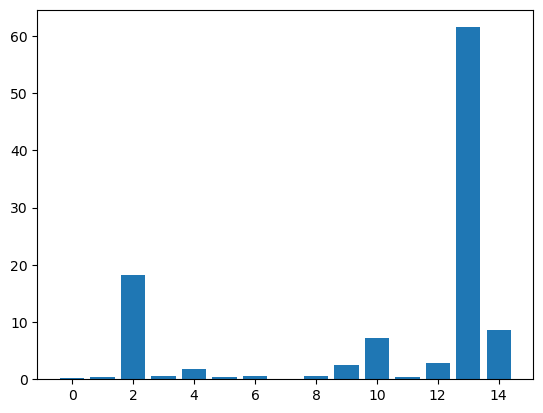

In [65]:

pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()


In [66]:

gnb = GaussianNB()

gnb.fit(X_train_fs, y_train)


GaussianNB()

In [67]:

y_pred = gnb.predict(X_test_fs)

In [68]:
#Accuracy score on Test and Train

from sklearn.metrics import accuracy_score
print("\nAccuracy score: %f" %(accuracy_score(y_test,y_pred) * 100))



Accuracy score: 65.517241
